In [1]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# Load an image for prediction (for example, from a file)
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import cv2

import numpy as np

import albumentations as A
from albumentations.pytorch import ToTensorV2

import os
import cv2
import torch
import timm
import time
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os


Found 400 files belonging to 3 classes.
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 511ms/step - accuracy: 0.5761 - loss: 0.8545
Evaluation Results on Real-World Data:
Loss: 0.8712793588638306
Accuracy: 0.5699999928474426
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


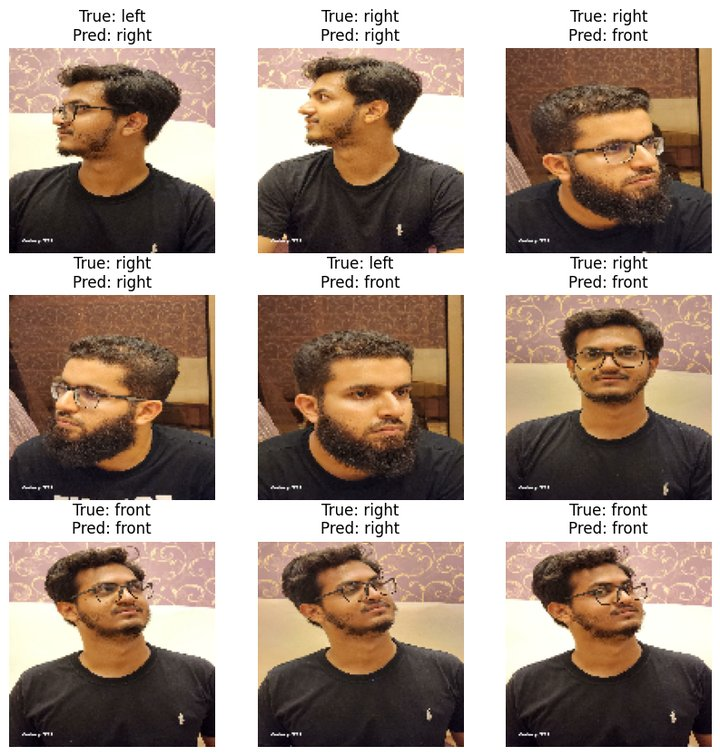

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt

# Set image size as per your model
IMG_SIZE = (128, 128)

# Load the trained model
model = load_model('../../models/face_dir_further.keras')  # Path to your saved model

# Path to your real-world image folder (organized in 'front', 'left', 'right' directories)
REAL_WORLD_IMAGE_PATH = '../../Datasets/personal_data_small1'

# Create a dataset from your real-world images
real_world_ds = image_dataset_from_directory(
    REAL_WORLD_IMAGE_PATH,
    image_size=IMG_SIZE,
    batch_size=32,  # Same batch size as during training
    label_mode='int',  # Labels will be assigned as 0, 1, 2 based on folder names
)

# Preprocess the images (same preprocessing as during training)
@tf.function
def preprocess_image(image):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image

# Apply preprocessing to the dataset
real_world_ds = real_world_ds.map(lambda x, y: (preprocess_image(x), y))

# Evaluate the model on the real-world dataset
loss, accuracy = model.evaluate(real_world_ds)

print(f"Evaluation Results on Real-World Data:")
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

# Optionally: Visualize some predictions
def plot_images(images, labels, predictions, class_names):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[predictions[i]]}")
        plt.axis("off")
    plt.show()

# Predict on the real-world dataset
predictions = []
true_labels = []
for images, labels in real_world_ds:
    preds = model.predict(images)
    predictions.extend(np.argmax(preds, axis=-1))  # Get class with highest probability
    true_labels.extend(labels.numpy())

# Class names (based on your folder names)
class_names = ['front', 'left', 'right']

# Plot some random images with predictions
plot_images(real_world_ds.take(1).get_single_element()[0], true_labels, predictions, class_names)


In [ ]:
# import os
# import shutil
# from sklearn.model_selection import train_test_split

# # Path to your images
# image_dir = "../../Datasets/personal_data_small"

# # Categories for your images
# categories = ['front', 'left', 'right']

# # Create new directories for train, val, and test
# os.makedirs(os.path.join(image_dir, 'train'), exist_ok=True)
# os.makedirs(os.path.join(image_dir, 'val'), exist_ok=True)
# os.makedirs(os.path.join(image_dir, 'test'), exist_ok=True)

# # Loop through categories and split images
# for category in categories:
#     category_path = os.path.join(image_dir, category)
    
#     # Get all images for the category
#     images = [f for f in os.listdir(category_path) if f.endswith('.jpg') or f.endswith('.png')]
    
#     # Split the data into train, validation, and test
#     train_images, temp_images = train_test_split(images, test_size=0.2, random_state=42)  # 80% train, 20% temp (val + test)
#     val_images, test_images = train_test_split(temp_images, test_size=0.5, random_state=42)  # 10% val, 10% test
    
#     # Create directories for the category inside train, val, and test
#     os.makedirs(os.path.join(image_dir, 'train', category), exist_ok=True)
#     os.makedirs(os.path.join(image_dir, 'val', category), exist_ok=True)
#     os.makedirs(os.path.join(image_dir, 'test', category), exist_ok=True)
    
#     # Copy the images into their respective directories
#     for img in train_images:
#         shutil.copy(os.path.join(category_path, img), os.path.join(image_dir, 'train', category, img))
    
#     for img in val_images:
#         shutil.copy(os.path.join(category_path, img), os.path.join(image_dir, 'val', category, img))
    
#     for img in test_images:
#         shutil.copy(os.path.join(category_path, img), os.path.join(image_dir, 'test', category, img))


In [6]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os

# Paths to the split data
DATASET_PATH = "../../Datasets/personal_data_small"

# Image size and batch size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Load the train, validation, and test datasets
train_ds = image_dataset_from_directory(
    os.path.join(DATASET_PATH, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = image_dataset_from_directory(
    os.path.join(DATASET_PATH, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

test_ds = image_dataset_from_directory(
    os.path.join(DATASET_PATH, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)


Found 319 files belonging to 3 classes.
Found 40 files belonging to 3 classes.
Found 41 files belonging to 3 classes.


In [7]:
from tensorflow.keras import layers
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.25),  # Increased rotation
    layers.RandomZoom(0.2),  # Increased zoom
    layers.RandomContrast(0.3),  # Increased contrast adjustment
    layers.RandomBrightness(0.3),  # Increased brightness adjustment
    layers.RandomTranslation(0.2, 0.2),  # Increased translation range
    layers.GaussianNoise(0.05),  # Added noise
    layers.RandomHeight(0.1),  # Random height adjustment
    layers.RandomWidth(0.1),  # Random width adjustment
])


In [13]:
# Augment the training data
train_ds_augmented = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))


In [19]:
from tensorflow.keras.models import load_model

# Load the pre-trained model
model = load_model("../../models/face_dir_further.keras")


In [14]:
# Freeze all layers in the pre-trained model to avoid retraining them
for layer in model.layers:
    layer.trainable = False



In [15]:
from tensorflow.keras.optimizers import Adam

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-5),  # Use a low learning rate for fine-tuning
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks to save the best model and stop early if validation loss doesn't improve
checkpoint = ModelCheckpoint("fine_tuned_model.keras", save_best_only=True, monitor="val_accuracy", mode="max", verbose=1)
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)


In [17]:
history = model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=20,
    verbose=1,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.4568 - loss: 1.1030
Epoch 1: val_accuracy improved from -inf to 0.52500, saving model to fine_tuned_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 488ms/step - accuracy: 0.4597 - loss: 1.0978 - val_accuracy: 0.5250 - val_loss: 0.8682
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.4436 - loss: 1.0959
Epoch 2: val_accuracy did not improve from 0.52500
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step - accuracy: 0.4415 - loss: 1.1016 - val_accuracy: 0.5250 - val_loss: 0.8682
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.4562 - loss: 1.1999
Epoch 3: val_accuracy did not improve from 0.52500
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 226ms/step - accuracy: 0.4566 - loss: 1.2021 - val_accuracy: 0.5250 - val_loss: 0.8682
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.4894 - loss: 1.1082
Epoch 4: val_accuracy did not improve from 0.52500
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step - accuracy: 0.4868 

In [20]:
# Example: unfreeze from layer 100 onward
base_model = model.layers[1]  # Assuming base_model is 2nd layer in full model
base_model.trainable = True

# Freeze first 100 layers to retain pretrained features
for layer in base_model.layers[:100]:
    layer.trainable = False


In [21]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),  # instead of 1e-5
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [22]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.3),
    layers.RandomBrightness(0.2)
])


In [23]:
train_ds_augmented = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))


In [24]:
from sklearn.utils import class_weight
import numpy as np

# Get class distribution
y_train = np.concatenate([y.numpy() for x, y in train_ds], axis=0)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))


In [25]:
model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights_dict
)


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.4435 - loss: 1.1489
Epoch 1: val_accuracy improved from 0.52500 to 0.55000, saving model to fine_tuned_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 471ms/step - accuracy: 0.4422 - loss: 1.1518 - val_accuracy: 0.5500 - val_loss: 0.8469
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.4106 - loss: 1.2314
Epoch 2: val_accuracy did not improve from 0.55000
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 216ms/step - accuracy: 0.4120 - loss: 1.2253 - val_accuracy: 0.5500 - val_loss: 0.8290
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.4628 - loss: 1.0595
Epoch 3: val_accuracy did not improve from 0.55000
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.4657 - loss: 1.0584 - val_accuracy: 0.5250 - val_loss: 0.8148
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.4449 - loss: 1.1204
Epoch 4: val_accuracy did not improve from 0.55000
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - accuracy: 0.4

In [26]:
model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights_dict
)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.6088 - loss: 0.9528
Epoch 1: val_accuracy did not improve from 0.70000
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - accuracy: 0.6087 - loss: 0.9481 - val_accuracy: 0.7000 - val_loss: 0.7138
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.5427 - loss: 1.0485
Epoch 2: val_accuracy improved from 0.70000 to 0.75000, saving model to fine_tuned_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 248ms/step - accuracy: 0.5424 - loss: 1.0464 - val_accuracy: 0.7500 - val_loss: 0.7099
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.5692 - loss: 0.9586
Epoch 3: val_accuracy did not improve from 0.75000
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 211ms/step - accuracy: 0.5676 - loss: 0.9604 - val_accuracy: 0.7000 - val_loss: 0.7109
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.5919 - loss: 0.9481
Epoch 4: val_accuracy did not improve from 0.75000
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - accuracy: 0.59

In [28]:
model.save("../../models/face_dir_further_eval1.keras")


In [29]:
ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)


In [31]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

# Fit the model
model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, checkpoint, reduce_lr],
    class_weight=class_weights_dict
)


Epoch 1/50


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 254ms/step - accuracy: 0.7060 - loss: 0.7496 - val_accuracy: 0.7750 - val_loss: 0.6770 - learning_rate: 1.0000e-04
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 252ms/step - accuracy: 0.6662 - loss: 0.8216 - val_accuracy: 0.7750 - val_loss: 0.6762 - learning_rate: 1.0000e-04
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 252ms/step - accuracy: 0.6863 - loss: 0.7531 - val_accuracy: 0.7750 - val_loss: 0.6749 - learning_rate: 1.0000e-04
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 255ms/step - accuracy: 0.6951 - loss: 0.7383 - val_accuracy: 0.7750 - val_loss: 0.6739 - learning_rate: 1.0000e-04
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - accuracy: 0.6876 - loss: 0.7719 - val_accuracy: 0.7750 - val_loss: 0.6752 - learning_rate: 1.0000e-04
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.5902 - loss: 0.8115 - val_accuracy: 0.7750 - val_loss: 0.6765 - learning_rate: 1.0000e-04
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.6769 - lo

In [2]:
# Load the trained model
model = load_model('../../models/face_dir_further_eval1.keras')  # Path to your saved model

In [33]:
# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(test_ds)

print(f"Test Set Evaluation:")
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.9408 - loss: 0.5438
Test Set Evaluation:
Loss: 0.5878
Accuracy: 0.9268


Found 41 files belonging to 3 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


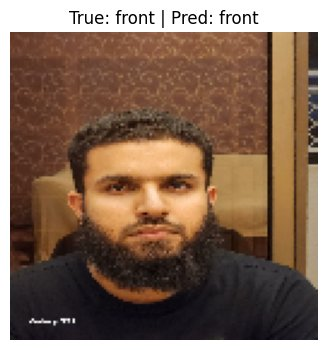

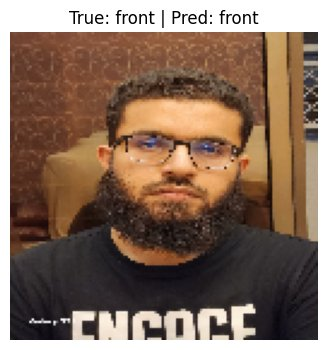

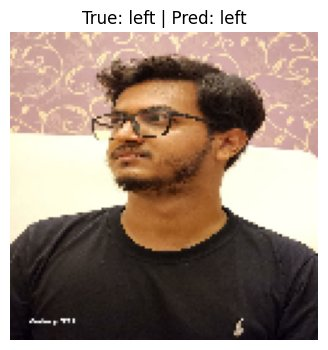

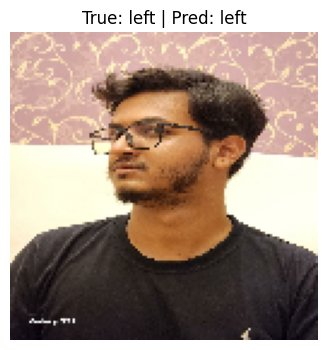

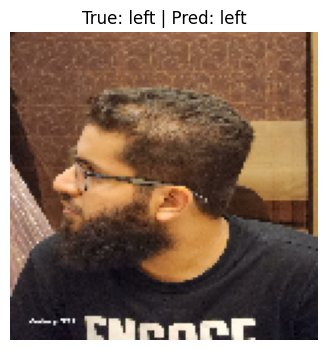

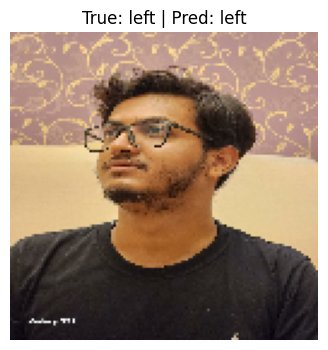

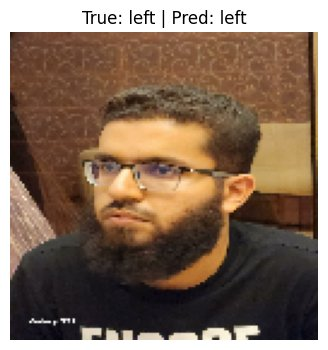

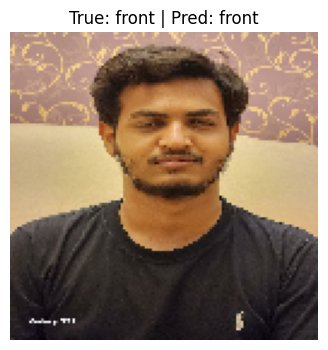

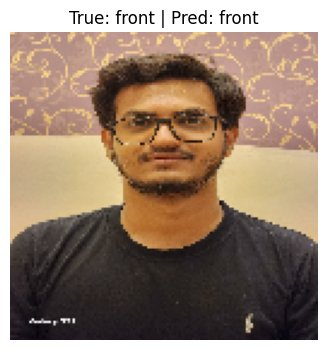

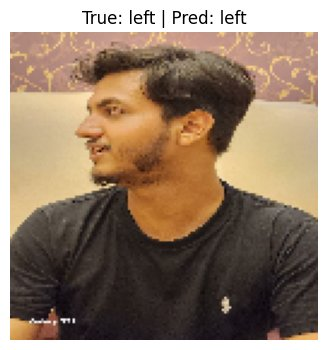

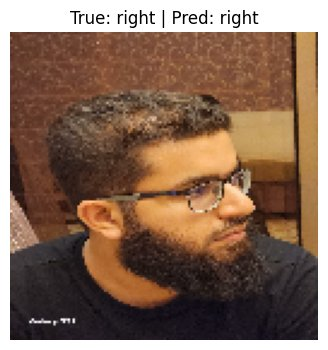

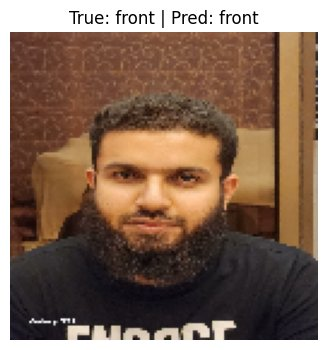

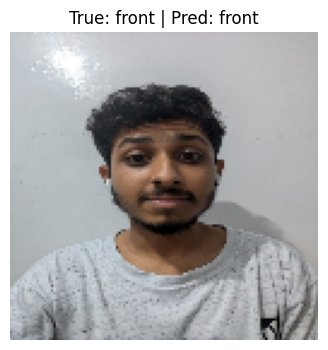

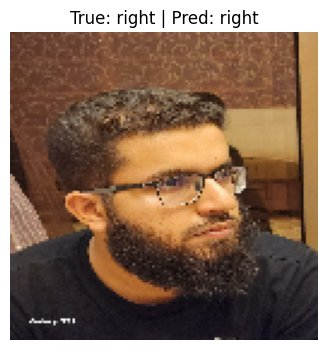

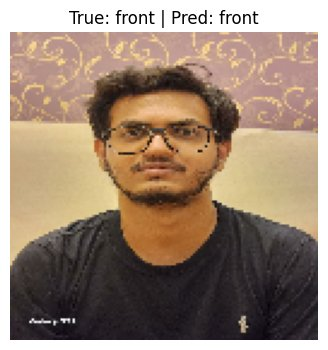

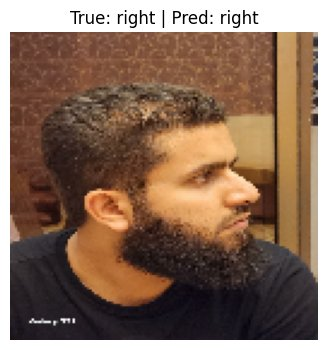

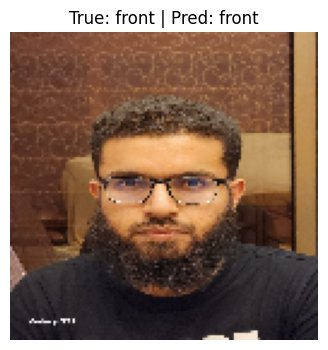

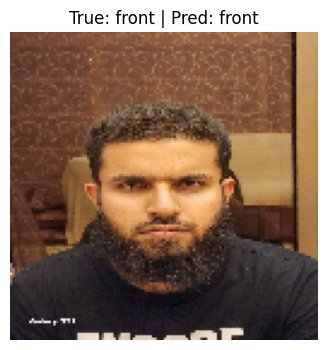

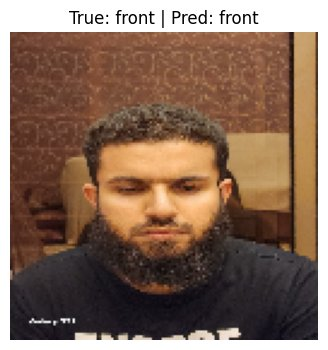

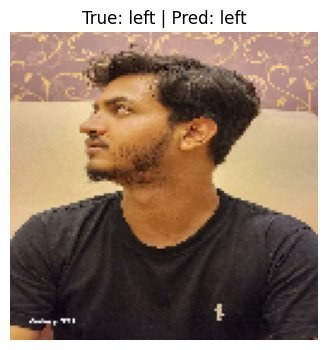

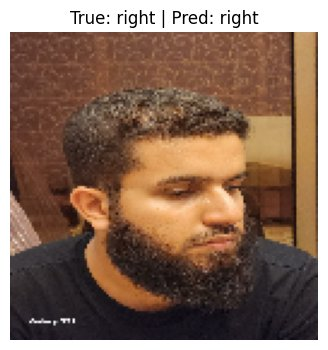

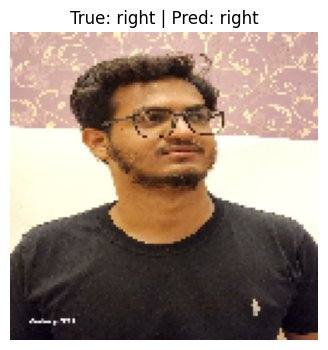

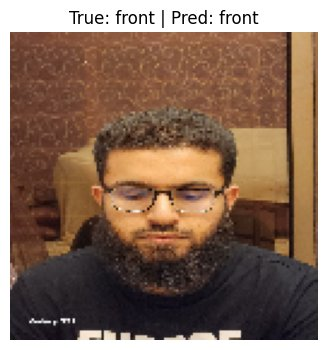

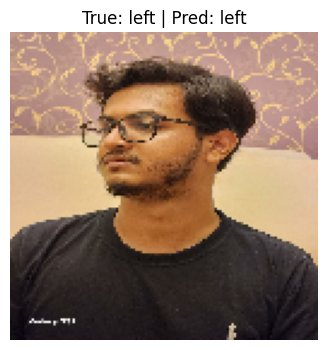

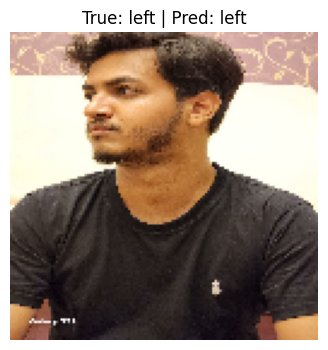

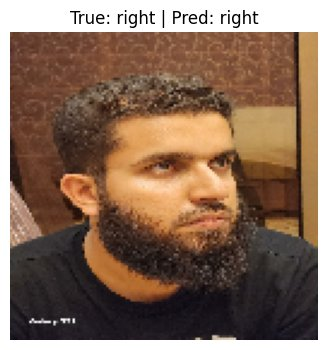

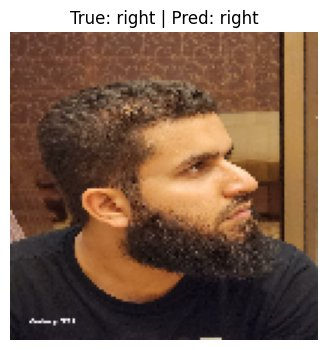

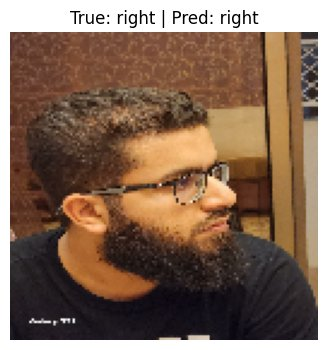

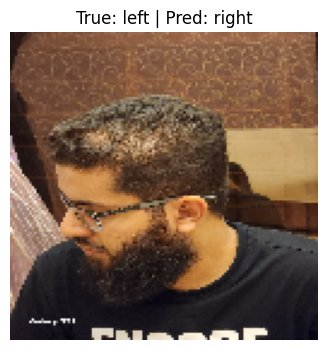

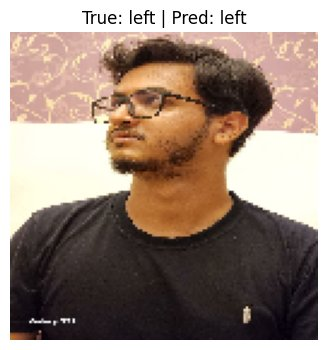

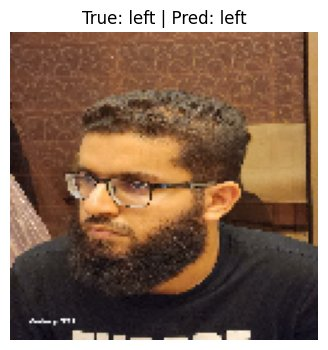

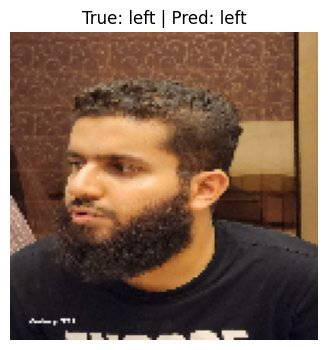

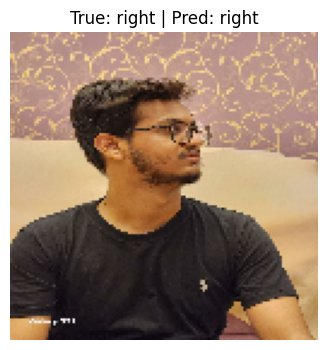

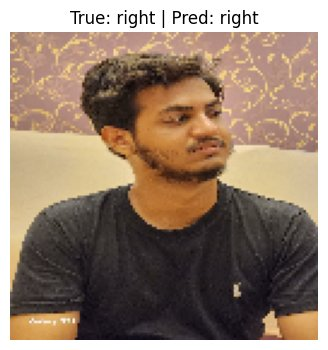

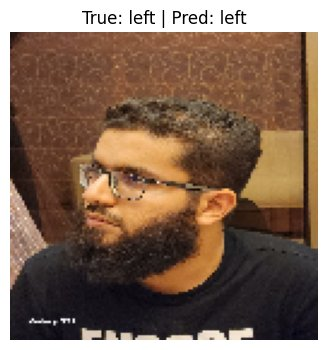

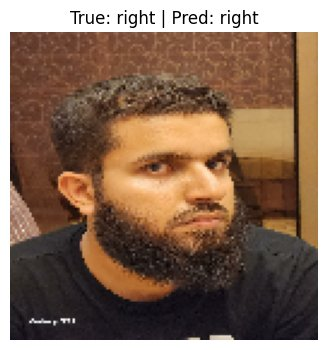

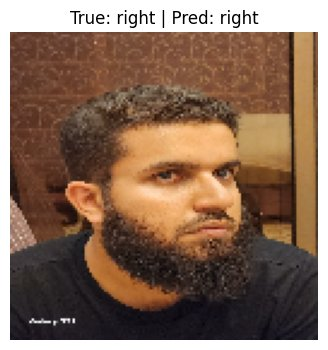

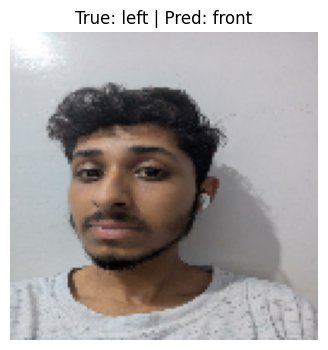

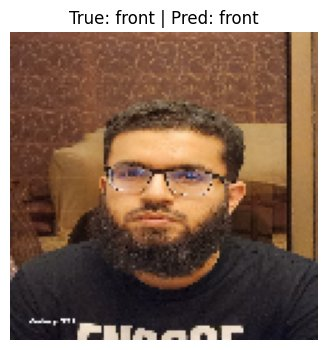

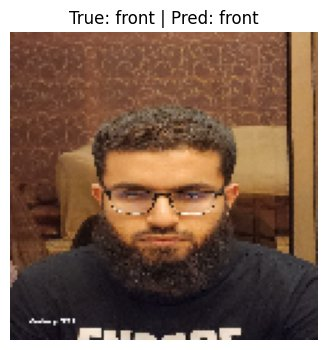

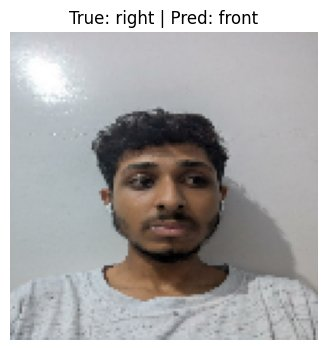

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Set image size as per your model
IMG_SIZE = (128, 128)

# Load the trained model
model = load_model('../../models/face_dir_further_eval1.keras')  # Path to your saved model

# Path to your real-world image folder (organized in 'front', 'left', 'right' directories)
REAL_WORLD_IMAGE_PATH = '../../Datasets/personal_data_small/test'

# Create a dataset from your real-world images
real_world_ds = tf.keras.preprocessing.image_dataset_from_directory(
    REAL_WORLD_IMAGE_PATH,
    image_size=IMG_SIZE,
    batch_size=32,  # Same batch size as during training
    label_mode='int',  # Labels will be assigned as 0, 1, 2 based on folder names
)

# Preprocess the images (same preprocessing as during training)
@tf.function
def preprocess_image(image):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image

# Apply preprocessing to the dataset
real_world_ds = real_world_ds.map(lambda x, y: (preprocess_image(x), y))

# Class names (based on folder names)
class_names = ['front', 'left', 'right']

# Function to display and save images with predictions
def display_and_save_images(images, labels, predictions, class_names):
    for i in range(len(images)):
        image = images[i].numpy().astype("uint8")
        label = class_names[labels[i]]
        pred = class_names[predictions[i]]

        # Plot the image
        plt.figure(figsize=(4, 4))
        plt.imshow(image)
        plt.title(f"True: {label} | Pred: {pred}")
        plt.axis("off")

        # Save the image with a name indicating true and predicted labels
        output_filename = f"output_image_{i}_true_{label}_pred_{pred}.png"
        plt.savefig(output_filename)

        # Display the image
        plt.show()

# Store images, labels, and predictions
predictions = []
true_labels = []
image_batch = []

# Iterate over the dataset and store images, labels, and predictions
for images, labels in real_world_ds:
    image_batch.extend(images)
    true_labels.extend(labels.numpy())
    
    # Predict on each batch
    preds = model.predict(images)
    predictions.extend(np.argmax(preds, axis=-1))  # Get class with highest probability

# Display and save images with predictions
display_and_save_images(image_batch, true_labels, predictions, class_names)


Found 23 files belonging to 3 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


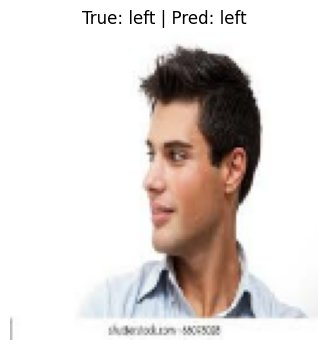

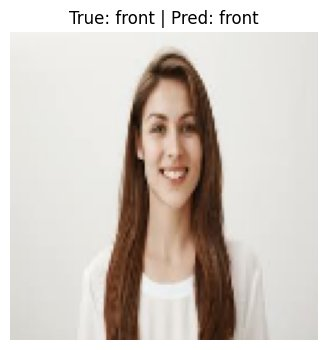

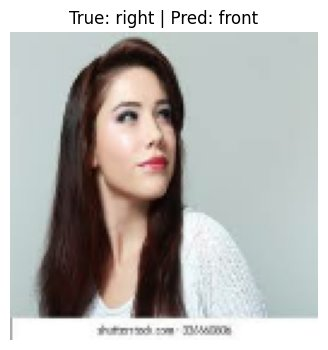

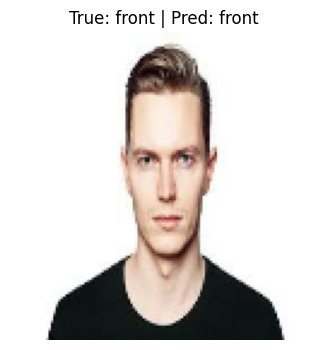

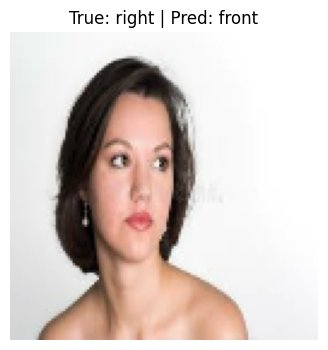

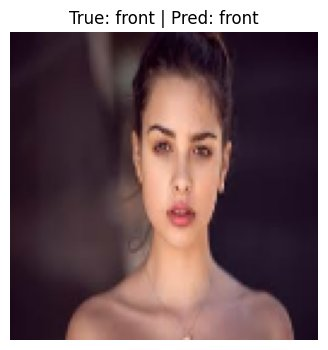

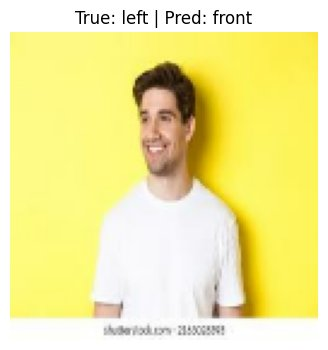

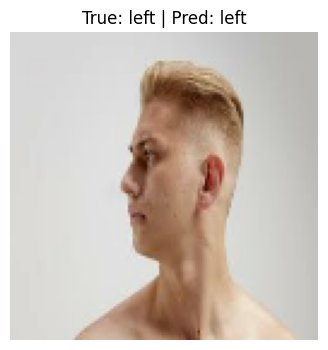

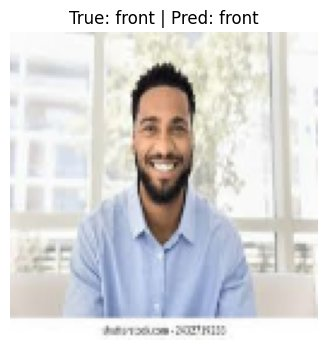

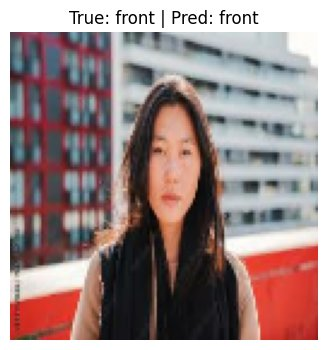

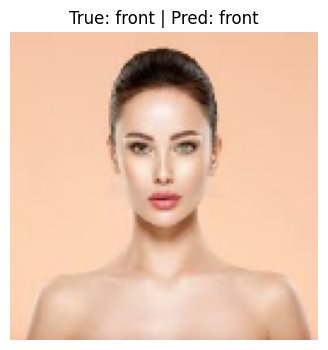

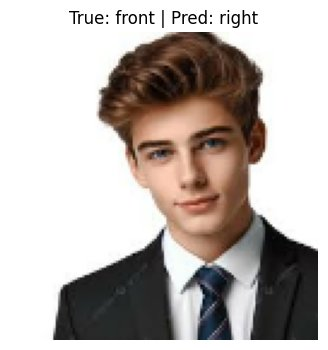

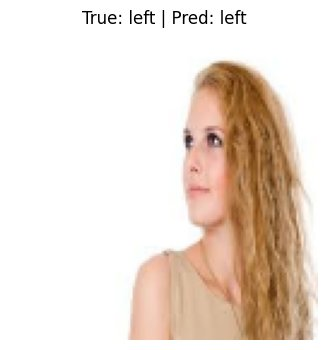

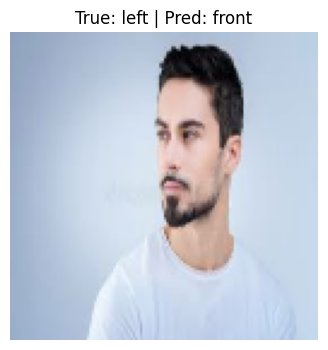

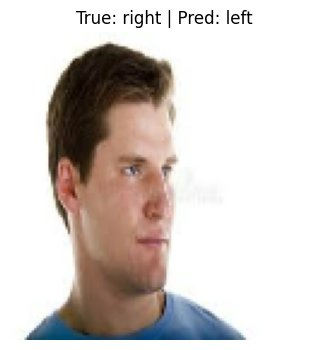

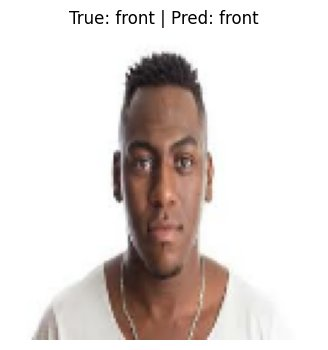

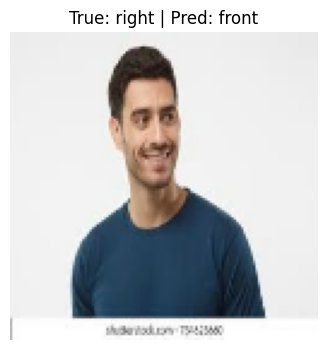

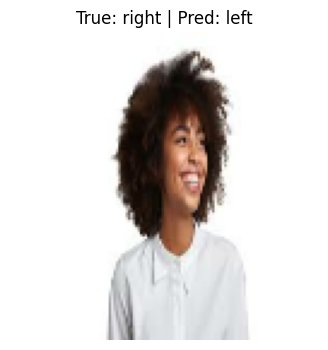

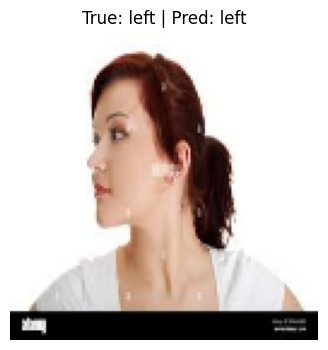

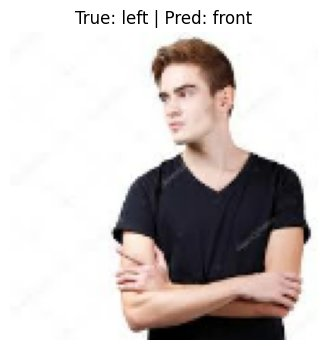

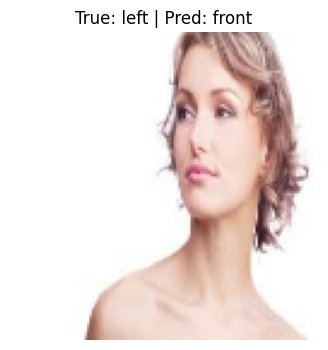

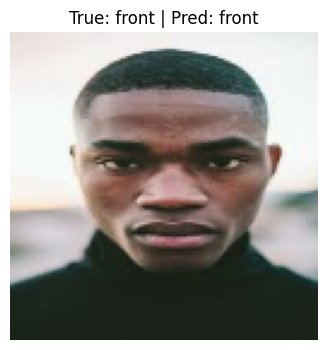

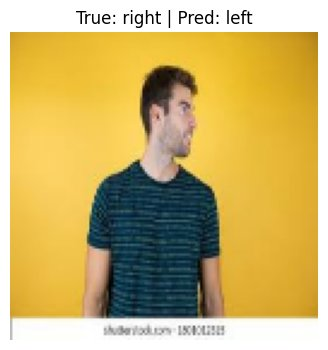

In [5]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Set image size as per your model
IMG_SIZE = (128, 128)

# Load the trained model
model = load_model('../../models/face_dir_further_eval1.keras')  # Path to your saved model

# Path to your real-world image folder (organized in 'front', 'left', 'right' directories)
REAL_WORLD_IMAGE_PATH = '../../Datasets/more_test'

# Create a dataset from your real-world images
real_world_ds = tf.keras.preprocessing.image_dataset_from_directory(
    REAL_WORLD_IMAGE_PATH,
    image_size=IMG_SIZE,
    batch_size=32,  # Same batch size as during training
    label_mode='int',  # Labels will be assigned as 0, 1, 2 based on folder names
)

# Preprocess the images (same preprocessing as during training)
@tf.function
def preprocess_image(image):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image

# Apply preprocessing to the dataset
real_world_ds = real_world_ds.map(lambda x, y: (preprocess_image(x), y))

# Class names (based on folder names)
class_names = ['front', 'left', 'right']

# Function to display and save images with predictions
def display_and_save_images(images, labels, predictions, class_names):
    for i in range(len(images)):
        image = images[i].numpy().astype("uint8")
        label = class_names[labels[i]]
        pred = class_names[predictions[i]]

        # Plot the image
        plt.figure(figsize=(4, 4))
        plt.imshow(image)
        plt.title(f"True: {label} | Pred: {pred}")
        plt.axis("off")

        # Save the image with a name indicating true and predicted labels
        output_filename = f"output_image_{i}_true_{label}_pred_{pred}.png"
        plt.savefig(output_filename)

        # Display the image
        plt.show()

# Store images, labels, and predictions
predictions = []
true_labels = []
image_batch = []

# Iterate over the dataset and store images, labels, and predictions
for images, labels in real_world_ds:
    image_batch.extend(images)
    true_labels.extend(labels.numpy())
    
    # Predict on each batch
    preds = model.predict(images)
    predictions.extend(np.argmax(preds, axis=-1))  # Get class with highest probability

# Display and save images with predictions
display_and_save_images(image_batch, true_labels, predictions, class_names)


In [2]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import time

# Set image size and class names
IMG_SIZE = (128, 128)
class_names = ['front', 'left', 'right']

# Load the trained model
model = load_model('../../models/face_dir_further_eval1.keras')

# Preprocess function (same as used in test dataset)
def preprocess_image_cv(image_bgr):
    # Resize and convert BGR to RGB
    image_rgb = cv2.cvtColor(cv2.resize(image_bgr, IMG_SIZE), cv2.COLOR_BGR2RGB)
    
    # Convert to float32 and normalize like in `image_dataset_from_directory`
    image_rgb = tf.convert_to_tensor(image_rgb, dtype=tf.float32)
    image_rgb = tf.keras.applications.efficientnet.preprocess_input(image_rgb)
    
    # Add batch dimension
    return tf.expand_dims(image_rgb, axis=0)

# Open webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam")
    exit()

frame_count = 0
start_time = time.time()
frame_skip = 5  # Only process every 5th frame

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame")
        break

    if frame_count % frame_skip == 0:
        input_tensor = preprocess_image_cv(frame)
        prediction = model.predict(input_tensor)
        predicted_label = class_names[np.argmax(prediction)]

        # Overlay prediction text on the frame
        cv2.putText(frame, f"Pred: {predicted_label}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Show frame
    cv2.imshow("Webcam Prediction", frame)

    # Calculate FPS
    frame_count += 1
    elapsed_time = time.time() - start_time
    if elapsed_time > 1:
        fps = frame_count / elapsed_time
        print(f"FPS: {fps:.2f}")
        frame_count = 0
        start_time = time.time()

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
FPS: 0.29
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
FPS: 20.69
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
FPS: 19.64
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
FPS: 27.66
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
FPS: 26.99
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/st

In [3]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import time

# Set image size and class names
IMG_SIZE = (128, 128)
class_names = ['front', 'left', 'right']

# Load the trained model
model = load_model('../../models/face_dir_further_eval1.keras')

# Preprocess function
def preprocess_image_cv(image_bgr):
    image_rgb = cv2.cvtColor(cv2.resize(image_bgr, IMG_SIZE), cv2.COLOR_BGR2RGB)
    image_rgb = tf.convert_to_tensor(image_rgb, dtype=tf.float32)
    image_rgb = tf.keras.applications.efficientnet.preprocess_input(image_rgb)
    return tf.expand_dims(image_rgb, axis=0)

# Open webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam")
    exit()

frame_count = 0
start_time = time.time()
frame_skip = 5  # Process every 5th frame
latest_prediction = "Predicting..."

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame")
        break

    # Only run prediction on every Nth frame
    if frame_count % frame_skip == 0:
        input_tensor = preprocess_image_cv(frame)
        prediction = model.predict(input_tensor, verbose=0)
        latest_prediction = class_names[np.argmax(prediction)]

    # Always overlay the most recent prediction
    cv2.putText(frame, f"Pred: {latest_prediction}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Show the frame
    cv2.imshow("Webcam Prediction", frame)

    # FPS calculation
    frame_count += 1
    elapsed_time = time.time() - start_time
    if elapsed_time > 1:
        fps = frame_count / elapsed_time
        print(f"FPS: {fps:.2f}")
        frame_count = 0
        start_time = time.time()

    # Exit on 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


FPS: 0.36
FPS: 23.70
FPS: 21.87
FPS: 23.79
FPS: 24.18
FPS: 19.32
FPS: 19.17
FPS: 20.77
FPS: 21.83
FPS: 23.94
FPS: 24.69
FPS: 22.76
FPS: 18.75
FPS: 20.48
FPS: 23.96
FPS: 24.95
FPS: 23.93
FPS: 18.98
FPS: 24.76
FPS: 9.81
FPS: 20.49
